In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/swin-transformer/vgg16_final.keras
/kaggle/input/swin-transformer/__results__.html
/kaggle/input/swin-transformer/__notebook__.ipynb
/kaggle/input/swin-transformer/__output__.json
/kaggle/input/swin-transformer/vgg16_best.keras
/kaggle/input/swin-transformer/vgg16_final.h5
/kaggle/input/swin-transformer/custom.css
/kaggle/input/swin-transformer/__results___files/__results___20_0.png
/kaggle/input/swin-transformer/__results___files/__results___22_1.png
/kaggle/input/resnet50/__results__.html
/kaggle/input/resnet50/kidney_resnet_final.keras
/kaggle/input/resnet50/__notebook__.ipynb
/kaggle/input/resnet50/kidney_resnet_balanced.keras
/kaggle/input/resnet50/best_resnet_kidney.keras
/kaggle/input/resnet50/__output__.json
/kaggle/input/resnet50/custom.css
/kaggle/input/resnet50/__results___files/__results___25_0.png
/kaggle/input/resnet50/__results___files/__results___27_1.png
/kaggle/input/resnet50/__results___files/__results___4_0.png
/kaggle/input/ct-kidney-dataset-normal-cy

In [3]:
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'   # 0 = all messages, 1 = info, 2 = warning, 3 = error only
import warnings
warnings.filterwarnings('ignore')
import logging
logging.getLogger('tensorflow').setLevel(logging.ERROR)
logging.getLogger('absl').setLevel(logging.ERROR)
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)




2025-11-18 07:28:15.387635: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1763450895.574725      48 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1763450895.626985      48 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

In [4]:
IMG_SIZE = (224, 224)
BATCH = 16

BASE_DIR = "/kaggle/input/ct-kidney-dataset-normal-cyst-tumor-and-stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone"

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.10,
    width_shift_range=0.08,
    height_shift_range=0.08,
    horizontal_flip=True,
    validation_split=0.2
)

train_gen = train_datagen.flow_from_directory(
    BASE_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_gen = train_datagen.flow_from_directory(
    BASE_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

print("Classes:", train_gen.class_indices)


Found 9957 images belonging to 1 classes.
Found 2489 images belonging to 1 classes.
Classes: {'CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone': 0}


In [5]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.models import Model

base_model = VGG16(
    weights="/kaggle/working/vgg16_weights_tf_dim_ordering_tf_kernels_notop.h5",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False   # freeze base layers


ValueError: The `weights` argument should be either `None` (random initialization), 'imagenet' (pre-training on ImageNet), or the path to the weights file to be loaded.  Received: weights=/kaggle/working/vgg16_weights_tf_dim_ordering_tf_kernels_notop.h5

In [6]:
import os

for root, dirs, files in os.walk("/kaggle", topdown=True):
    for filename in files:
        if "vgg16" in filename.lower():
            print(os.path.join(root, filename))


/kaggle/input/swin-transformer/vgg16_final.keras
/kaggle/input/swin-transformer/vgg16_best.keras
/kaggle/input/swin-transformer/vgg16_final.h5
/kaggle/input/vgg16/keras/default/1/vgg16_weights_tf_dim_ordering_tf_kernels_notop (1).h5


In [7]:
base_model = VGG16(
    weights="/kaggle/input/vgg16/keras/default/1/vgg16_weights_tf_dim_ordering_tf_kernels_notop (1).h5",
    include_top=False,
    input_shape=(224, 224, 3)
)


I0000 00:00:1763450938.742731      48 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1763450938.743464      48 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [8]:
from tensorflow.keras.applications import VGG16

weights_path = "/kaggle/input/vgg16/keras/default/1/vgg16_weights_tf_dim_ordering_tf_kernels_notop (1).h5"

base_model = VGG16(
    weights=weights_path,       # full path works
    include_top=False,
    input_shape=(224,224,3)
)
print("Loaded base_model with weights from:", weights_path)


Loaded base_model with weights from: /kaggle/input/vgg16/keras/default/1/vgg16_weights_tf_dim_ordering_tf_kernels_notop (1).h5


In [9]:
from tensorflow.keras.applications import VGG16

weights_path = "/kaggle/input/vgg16/keras/default/1/vgg16_weights_tf_dim_ordering_tf_kernels_notop (1).h5"

# create base model without loading any weights
base_model = VGG16(weights=None, include_top=False, input_shape=(224,224,3))

# load weights into the model
base_model.load_weights(weights_path)
print("Weights loaded via load_weights()")


Weights loaded via load_weights()


In [10]:
base_model.load_weights(weights_path, by_name=True)


In [11]:
import shutil
src = "/kaggle/input/vgg16/keras/default/1/vgg16_weights_tf_dim_ordering_tf_kernels_notop (1).h5"
dst = "/kaggle/working/vgg16_notop.h5"
shutil.copy(src, dst)
print("Copied to", dst)

from tensorflow.keras.applications import VGG16
base_model = VGG16(weights=dst, include_top=False, input_shape=(224,224,3))
print("Loaded from simpler path")


Copied to /kaggle/working/vgg16_notop.h5
Loaded from simpler path


In [12]:
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.models import Model

base_model.trainable = False

x = Flatten()(base_model.output)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(3, activation='softmax')(x)   # change 3 -> your # classes

model = Model(inputs=base_model.input, outputs=output)
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,138,243 (80.64 MB)

 Trainable params: 6,423,555 (24.50 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [14]:
from tensorflow.keras.layers import Flatten, Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model

# assume `base_model` already exists (VGG16 include_top=False)
# if not, load it as shown previously

# freeze base
base_model.trainable = False

# add a robust head (GlobalAveragePooling helps with different input sizes)
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.4)(x)
output = Dense(1, activation='sigmoid')(x)   # placeholder; will replace after we know num_classes

model = Model(inputs=base_model.input, outputs=output)


In [16]:
import os

for root, dirs, files in os.walk("/kaggle", topdown=True):
    for d in dirs:
        if d.lower() in ["train", "val", "valid", "validation", "test"]:
            print(os.path.join(root, d))


In [17]:
import os

for root, dirs, files in os.walk("/kaggle", topdown=True):
    for f in files:
        if f.lower().endswith((".jpg", ".png", ".jpeg")):
            print("Image file found at:", root)
            break


Image file found at: /kaggle/input/swin-transformer/__results___files
Image file found at: /kaggle/input/resnet50/__results___files
Image file found at: /kaggle/input/ct-kidney-dataset-normal-cyst-tumor-and-stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/Cyst
Image file found at: /kaggle/input/ct-kidney-dataset-normal-cyst-tumor-and-stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/Tumor
Image file found at: /kaggle/input/ct-kidney-dataset-normal-cyst-tumor-and-stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/Stone
Image file found at: /kaggle/input/ct-kidney-dataset-normal-cyst-tumor-and-stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/Normal


In [18]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.vgg16 import preprocess_input
import os

# DATASET PATH
dataset_path = "/kaggle/input/ct-kidney-dataset-normal-cyst-tumor-and-stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone"

IMAGE_SIZE = (224, 224)
BATCH_SIZE = 16

train_gen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.20,       # 80% train, 20% validation
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.05,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
).flow_from_directory(
    dataset_path,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'            # TRAIN
)

val_gen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.20        # SAME SPLIT
).flow_from_directory(
    dataset_path,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False,
    subset='validation'          # VALIDATION
)

# DETECT CLASSES
num_classes = train_gen.num_classes
print("Detected classes:", train_gen.class_indices)
print("Num classes:", num_classes)


Found 9959 images belonging to 4 classes.
Found 2487 images belonging to 4 classes.
Detected classes: {'Cyst': 0, 'Normal': 1, 'Stone': 2, 'Tumor': 3}
Num classes: 4


In [19]:
from tensorflow.keras import optimizers, losses, metrics

# rebuild final output according to num_classes
if num_classes == 2:
    final_activation = 'sigmoid'
    final_units = 1
    loss = 'binary_crossentropy'
    class_mode = 'binary'
else:
    final_activation = 'softmax'
    final_units = num_classes
    loss = 'categorical_crossentropy'
    class_mode = 'categorical'

# attach final layer
from tensorflow.keras.layers import Activation
x = model.layers[-3].output  # last Dense/Dropout before placeholder output; robust enough in this layout
# safer: rebuild head from base_model.output again to be explicit:
from tensorflow.keras.layers import GlobalAveragePooling2D
x = GlobalAveragePooling2D()(base_model.output)
x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.4)(x)
if final_units == 1:
    out = Dense(1, activation='sigmoid')(x)
else:
    out = Dense(final_units, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=out)

# compile
optimizer = optimizers.Adam(learning_rate=1e-4)
model.compile(optimizer=optimizer, loss=loss, metrics=['accuracy'])
model.summary()


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 15,109,700 (57.64 MB)

 Trainable params: 395,012 (1.51 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [20]:
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping

checkpoint = ModelCheckpoint("vgg16_best.h5", monitor='val_accuracy', save_best_only=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1, min_lr=1e-7)
earlystop = EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True, verbose=1)

callbacks = [checkpoint, reduce_lr, earlystop]


In [21]:
history1 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=20,
    callbacks=callbacks
)


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20


I0000 00:00:1763450988.284158     129 service.cc:148] XLA service 0x7852f800fbf0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1763450988.284958     129 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1763450988.284979     129 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1763450988.704405     129 cuda_dnn.cc:529] Loaded cuDNN version 90300


  2/623 ━━━━━━━━━━━━━━━━━━━━ 58s 94ms/step - accuracy: 0.2031 - loss: 6.4513   

I0000 00:00:1763450997.356739     129 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


623/623 ━━━━━━━━━━━━━━━━━━━━ 0s 302ms/step - accuracy: 0.4320 - loss: 2.7427
Epoch 1: val_accuracy improved from -inf to 0.67431, saving model to vgg16_best.h5


623/623 ━━━━━━━━━━━━━━━━━━━━ 224s 343ms/step - accuracy: 0.4321 - loss: 2.7412 - val_accuracy: 0.6743 - val_loss: 0.9115 - learning_rate: 1.0000e-04
Epoch 2/20
623/623 ━━━━━━━━━━━━━━━━━━━━ 0s 210ms/step - accuracy: 0.6690 - loss: 0.8855
Epoch 2: val_accuracy did not improve from 0.67431
623/623 ━━━━━━━━━━━━━━━━━━━━ 150s 240ms/step - accuracy: 0.6690 - loss: 0.8854 - val_accuracy: 0.6510 - val_loss: 0.9539 - learning_rate: 1.0000e-04
Epoch 3/20
623/623 ━━━━━━━━━━━━━━━━━━━━ 0s 210ms/step - accuracy: 0.7675 - loss: 0.6289
Epoch 3: val_accuracy improved from 0.67431 to 0.70728, saving model to vgg16_best.h5


623/623 ━━━━━━━━━━━━━━━━━━━━ 150s 240ms/step - accuracy: 0.7676 - loss: 0.6289 - val_accuracy: 0.7073 - val_loss: 0.8846 - learning_rate: 1.0000e-04
Epoch 4/20
623/623 ━━━━━━━━━━━━━━━━━━━━ 0s 211ms/step - accuracy: 0.8140 - loss: 0.4791
Epoch 4: val_accuracy did not improve from 0.70728
623/623 ━━━━━━━━━━━━━━━━━━━━ 150s 241ms/step - accuracy: 0.8140 - loss: 0.4791 - val_accuracy: 0.7021 - val_loss: 1.0310 - learning_rate: 1.0000e-04
Epoch 5/20
623/623 ━━━━━━━━━━━━━━━━━━━━ 0s 214ms/step - accuracy: 0.8545 - loss: 0.3937
Epoch 5: val_accuracy improved from 0.70728 to 0.71612, saving model to vgg16_best.h5


623/623 ━━━━━━━━━━━━━━━━━━━━ 152s 244ms/step - accuracy: 0.8545 - loss: 0.3937 - val_accuracy: 0.7161 - val_loss: 1.0052 - learning_rate: 1.0000e-04
Epoch 6/20
623/623 ━━━━━━━━━━━━━━━━━━━━ 0s 211ms/step - accuracy: 0.8777 - loss: 0.3280
Epoch 6: val_accuracy did not improve from 0.71612

Epoch 6: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
623/623 ━━━━━━━━━━━━━━━━━━━━ 151s 242ms/step - accuracy: 0.8777 - loss: 0.3280 - val_accuracy: 0.6856 - val_loss: 1.0757 - learning_rate: 1.0000e-04
Epoch 7/20
623/623 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step - accuracy: 0.8956 - loss: 0.2676
Epoch 7: val_accuracy improved from 0.71612 to 0.71974, saving model to vgg16_best.h5


623/623 ━━━━━━━━━━━━━━━━━━━━ 151s 243ms/step - accuracy: 0.8956 - loss: 0.2676 - val_accuracy: 0.7197 - val_loss: 1.0718 - learning_rate: 5.0000e-05
Epoch 8/20
623/623 ━━━━━━━━━━━━━━━━━━━━ 0s 214ms/step - accuracy: 0.9048 - loss: 0.2512
Epoch 8: val_accuracy did not improve from 0.71974
623/623 ━━━━━━━━━━━━━━━━━━━━ 152s 244ms/step - accuracy: 0.9048 - loss: 0.2512 - val_accuracy: 0.7145 - val_loss: 1.1206 - learning_rate: 5.0000e-05
Epoch 9/20
623/623 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step - accuracy: 0.9173 - loss: 0.2219
Epoch 9: val_accuracy did not improve from 0.71974

Epoch 9: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-05.
623/623 ━━━━━━━━━━━━━━━━━━━━ 151s 242ms/step - accuracy: 0.9173 - loss: 0.2219 - val_accuracy: 0.7081 - val_loss: 1.1496 - learning_rate: 5.0000e-05
Epoch 9: early stopping
Restoring model weights from the end of the best epoch: 3.


In [22]:
# Unfreeze last conv block for fine-tuning
for layer in base_model.layers:
    if layer.name.startswith('block5_'):   # fine-tune only block5 layers
        layer.trainable = True
    else:
        layer.trainable = False

from tensorflow.keras.optimizers import Adam

# Re-compile with a lower LR for fine-tuning
model.compile(optimizer=Adam(1e-5), loss=loss, metrics=['accuracy'])

EPOCHS_STAGE2 = 10

history2 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS_STAGE2,
    callbacks=callbacks   # ⬅️ ONLY this, no workers / no use_multiprocessing
)


Epoch 1/10
623/623 ━━━━━━━━━━━━━━━━━━━━ 0s 217ms/step - accuracy: 0.8360 - loss: 0.4270
Epoch 1: val_accuracy did not improve from 0.71974
623/623 ━━━━━━━━━━━━━━━━━━━━ 160s 248ms/step - accuracy: 0.8361 - loss: 0.4269 - val_accuracy: 0.7029 - val_loss: 1.2501 - learning_rate: 1.0000e-05
Epoch 2/10
623/623 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step - accuracy: 0.9273 - loss: 0.1983
Epoch 2: val_accuracy improved from 0.71974 to 0.76196, saving model to vgg16_best.h5


623/623 ━━━━━━━━━━━━━━━━━━━━ 151s 242ms/step - accuracy: 0.9274 - loss: 0.1982 - val_accuracy: 0.7620 - val_loss: 1.0209 - learning_rate: 1.0000e-05
Epoch 3/10
623/623 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step - accuracy: 0.9500 - loss: 0.1339
Epoch 3: val_accuracy did not improve from 0.76196
623/623 ━━━━━━━━━━━━━━━━━━━━ 151s 242ms/step - accuracy: 0.9500 - loss: 0.1339 - val_accuracy: 0.7394 - val_loss: 1.3181 - learning_rate: 1.0000e-05
Epoch 4/10
623/623 ━━━━━━━━━━━━━━━━━━━━ 0s 211ms/step - accuracy: 0.9697 - loss: 0.0838
Epoch 4: val_accuracy improved from 0.76196 to 0.77644, saving model to vgg16_best.h5


623/623 ━━━━━━━━━━━━━━━━━━━━ 150s 241ms/step - accuracy: 0.9698 - loss: 0.0838 - val_accuracy: 0.7764 - val_loss: 1.1210 - learning_rate: 1.0000e-05
Epoch 5/10
623/623 ━━━━━━━━━━━━━━━━━━━━ 0s 214ms/step - accuracy: 0.9790 - loss: 0.0606
Epoch 5: val_accuracy did not improve from 0.77644

Epoch 5: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.
623/623 ━━━━━━━━━━━━━━━━━━━━ 151s 243ms/step - accuracy: 0.9790 - loss: 0.0606 - val_accuracy: 0.7756 - val_loss: 1.3063 - learning_rate: 1.0000e-05
Epoch 6/10
623/623 ━━━━━━━━━━━━━━━━━━━━ 0s 214ms/step - accuracy: 0.9884 - loss: 0.0315
Epoch 6: val_accuracy did not improve from 0.77644
623/623 ━━━━━━━━━━━━━━━━━━━━ 151s 243ms/step - accuracy: 0.9884 - loss: 0.0315 - val_accuracy: 0.7608 - val_loss: 1.4899 - learning_rate: 5.0000e-06
Epoch 7/10
623/623 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step - accuracy: 0.9907 - loss: 0.0277
Epoch 7: val_accuracy improved from 0.77644 to 0.78770, saving model to vgg16_best.h5


623/623 ━━━━━━━━━━━━━━━━━━━━ 151s 243ms/step - accuracy: 0.9907 - loss: 0.0277 - val_accuracy: 0.7877 - val_loss: 1.4036 - learning_rate: 5.0000e-06
Epoch 8/10
623/623 ━━━━━━━━━━━━━━━━━━━━ 0s 211ms/step - accuracy: 0.9927 - loss: 0.0220
Epoch 8: val_accuracy did not improve from 0.78770

Epoch 8: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-06.
623/623 ━━━━━━━━━━━━━━━━━━━━ 150s 240ms/step - accuracy: 0.9927 - loss: 0.0220 - val_accuracy: 0.7455 - val_loss: 1.6023 - learning_rate: 5.0000e-06
Epoch 8: early stopping
Restoring model weights from the end of the best epoch: 2.


In [25]:
import os, shutil, random
from pathlib import Path

DATASET_PATH = Path("/kaggle/working/data_split")
SOURCE = Path("/kaggle/input/ct-kidney-dataset-normal-cyst-tumor-and-stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone")

# remove old split
if DATASET_PATH.exists():
    shutil.rmtree(DATASET_PATH)

train_dir = DATASET_PATH / "train"
val_dir   = DATASET_PATH / "val"
test_dir  = DATASET_PATH / "test"

train_dir.mkdir(parents=True)
val_dir.mkdir(parents=True)
test_dir.mkdir(parents=True)

TRAIN_SPLIT = 0.70
VAL_SPLIT   = 0.15
TEST_SPLIT  = 0.15

random.seed(42)

for cls in SOURCE.iterdir():
    if cls.is_dir():
        files = [x for x in cls.iterdir() if x.suffix.lower() in [".jpg", ".png", ".jpeg"]]
        random.shuffle(files)

        n = len(files)
        n_train = int(n * TRAIN_SPLIT)
        n_val   = int(n * VAL_SPLIT)

        # create class folders
        (train_dir / cls.name).mkdir()
        (val_dir / cls.name).mkdir()
        (test_dir / cls.name).mkdir()

        for i, f in enumerate(files):
            if i < n_train:
                shutil.copy(f, train_dir / cls.name / f.name)
            elif i < n_train + n_val:
                shutil.copy(f, val_dir / cls.name / f.name)
            else:
                shutil.copy(f, test_dir / cls.name / f.name)

print("Dataset split complete!")


Dataset split complete!


In [27]:
train_gen = ImageDataGenerator(preprocess_input).flow_from_directory(
    DATASET_PATH / "train",
    target_size=(224,224),
    batch_size=16,
    class_mode="categorical"
)

val_gen = ImageDataGenerator(preprocess_input).flow_from_directory(
    DATASET_PATH / "val",
    target_size=(224,224),
    batch_size=16,
    class_mode="categorical",
    shuffle=False
)

test_gen = ImageDataGenerator(preprocess_input).flow_from_directory(
    DATASET_PATH / "test",
    target_size=(224,224),
    batch_size=16,
    class_mode="categorical",
    shuffle=False
)


Found 8710 images belonging to 4 classes.
Found 1865 images belonging to 4 classes.
Found 1871 images belonging to 4 classes.


In [28]:
test_loss, test_acc = model.evaluate(test_gen)
print("Test accuracy:", test_acc)


/usr/local/lib/python3.11/dist-packages/keras/src/legacy/preprocessing/image.py:1263: UserWarning: This ImageDataGenerator specifies `featurewise_center`, but it hasn't been fit on any training data. Fit it first by calling `.fit(numpy_data)`.
  warnings.warn(


117/117 ━━━━━━━━━━━━━━━━━━━━ 24s 208ms/step - accuracy: 0.7883 - loss: 0.6473
Test accuracy: 0.8246926665306091


In [29]:
# evaluate
test_loss, test_acc = model.evaluate(test_gen, verbose=1)
print("Test loss:", test_loss, "Test accuracy:", test_acc)

# predictions and confusion matrix
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

# predict probabilities
preds = model.predict(test_gen, verbose=1)
if final_units == 1:
    y_pred = (preds.ravel() > 0.5).astype(int)
else:
    y_pred = np.argmax(preds, axis=1)

y_true = test_gen.classes

print("Confusion matrix:")
print(confusion_matrix(y_true, y_pred))
print("Classification report:")
print(classification_report(y_true, y_pred, target_names=list(train_gen.class_indices.keys())))


117/117 ━━━━━━━━━━━━━━━━━━━━ 13s 112ms/step - accuracy: 0.7883 - loss: 0.6473
Test loss: 0.5655832886695862 Test accuracy: 0.8246926665306091
117/117 ━━━━━━━━━━━━━━━━━━━━ 15s 124ms/step
Confusion matrix:
[[451   4 102   0]
 [  2 657  90  14]
 [ 26   3 179   0]
 [ 41  35  11 256]]
Classification report:
              precision    recall  f1-score   support

        Cyst       0.87      0.81      0.84       557
      Normal       0.94      0.86      0.90       763
       Stone       0.47      0.86      0.61       208
       Tumor       0.95      0.75      0.84       343

    accuracy                           0.82      1871
   macro avg       0.81      0.82      0.79      1871
weighted avg       0.87      0.82      0.84      1871



/usr/local/lib/python3.11/dist-packages/keras/src/legacy/preprocessing/image.py:1263: UserWarning: This ImageDataGenerator specifies `featurewise_center`, but it hasn't been fit on any training data. Fit it first by calling `.fit(numpy_data)`.
  warnings.warn(


117/117 ━━━━━━━━━━━━━━━━━━━━ 14s 120ms/step


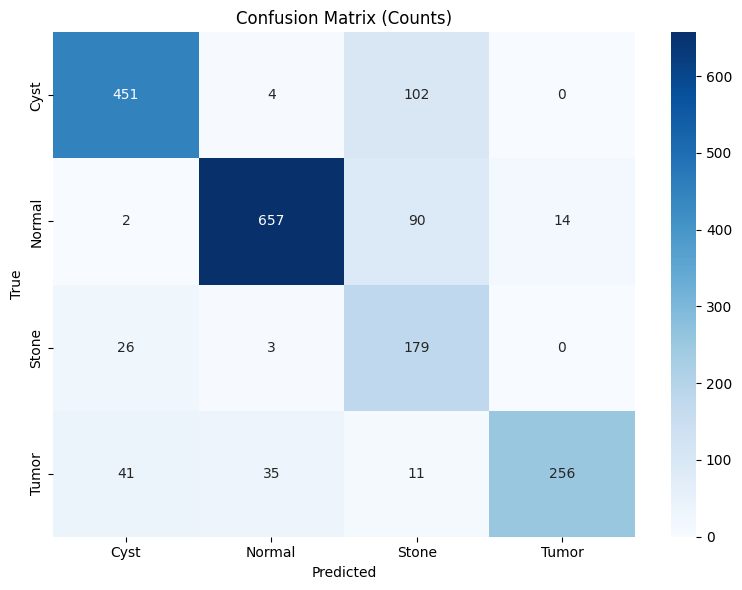

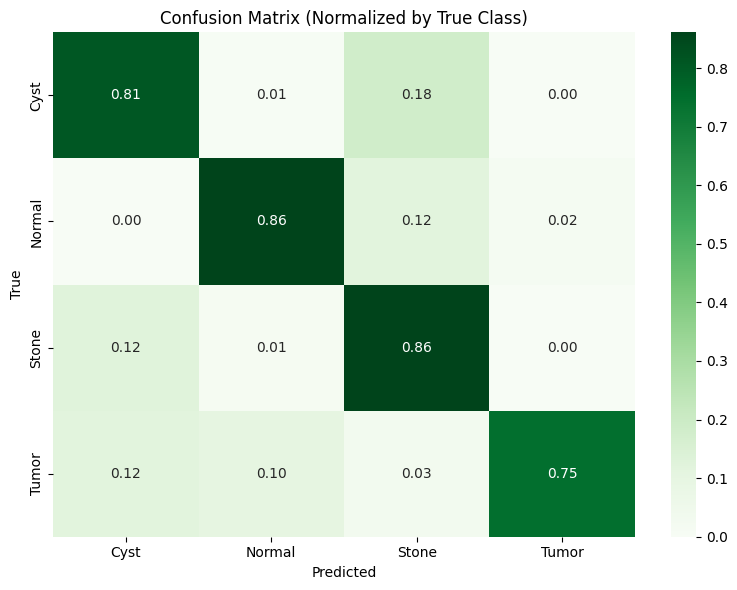

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import seaborn as sns

# Get true labels and predictions again (safest)
test_gen.reset()
preds = model.predict(test_gen, verbose=1)

# For multi-class
y_true = test_gen.classes
class_names = list(test_gen.class_indices.keys())

if preds.shape[1] == 1:
    y_pred = (preds.ravel() > 0.5).astype(int)
else:
    y_pred = np.argmax(preds, axis=1)

# 1) Raw confusion matrix (counts)
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (Counts)")
plt.tight_layout()
plt.show()

# 2) Normalized confusion matrix (per-class %)
cm_norm = confusion_matrix(y_true, y_pred, normalize='true')

plt.figure(figsize=(8,6))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Greens',
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (Normalized by True Class)")
plt.tight_layout()
plt.show()


Combined history1 + history2


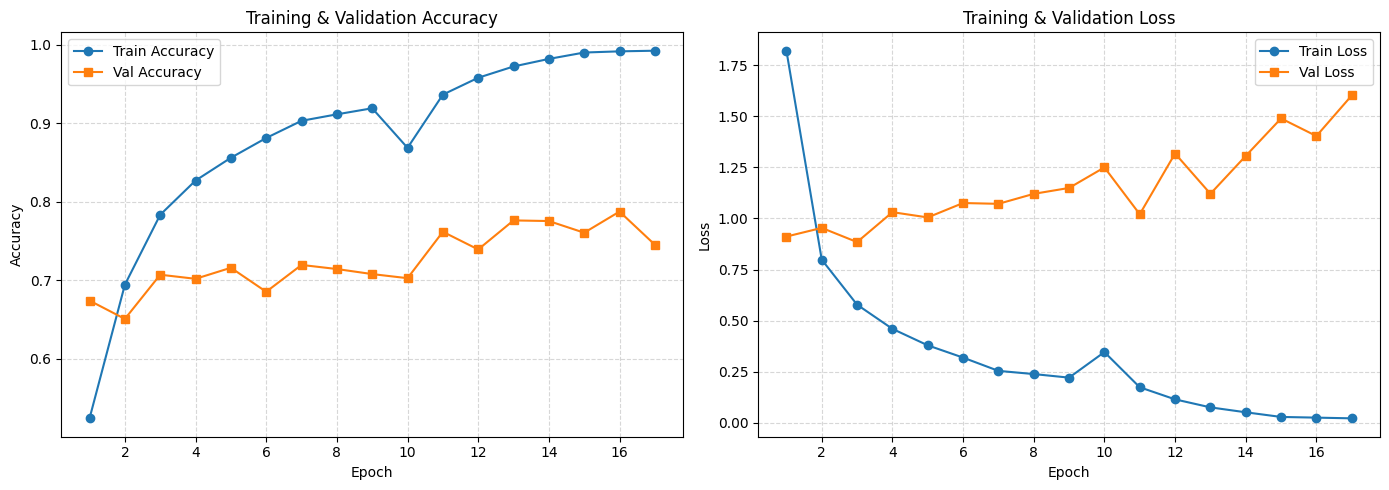

In [31]:
import matplotlib.pyplot as plt

# Collect history from stage 1
acc = history1.history['accuracy']
val_acc = history1.history['val_accuracy']
loss = history1.history['loss']
val_loss = history1.history['val_loss']

# If you did fine-tuning stage (history2), append it
try:
    acc += history2.history['accuracy']
    val_acc += history2.history['val_accuracy']
    loss += history2.history['loss']
    val_loss += history2.history['val_loss']
    print("Combined history1 + history2")
except NameError:
    print("Only history1 found (no fine-tuning history2).")

epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(14,5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, marker='o', label='Train Accuracy')
plt.plot(epochs_range, val_acc, marker='s', label='Val Accuracy')
plt.title('Training & Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, marker='o', label='Train Loss')
plt.plot(epochs_range, val_loss, marker='s', label='Val Loss')
plt.title('Training & Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()

plt.tight_layout()
plt.show()


In [33]:
# ✔ Save full model in recommended format
model.save("vgg16_finetuned_model.keras")
print("Saved: vgg16_finetuned_model.keras")

# ✔ Save only weights (MUST end with .weights.h5)
model.save_weights("vgg16_finetuned.weights.h5")
print("Saved: vgg16_finetuned.weights.h5")


Saved: vgg16_finetuned_model.keras
Saved: vgg16_finetuned.weights.h5


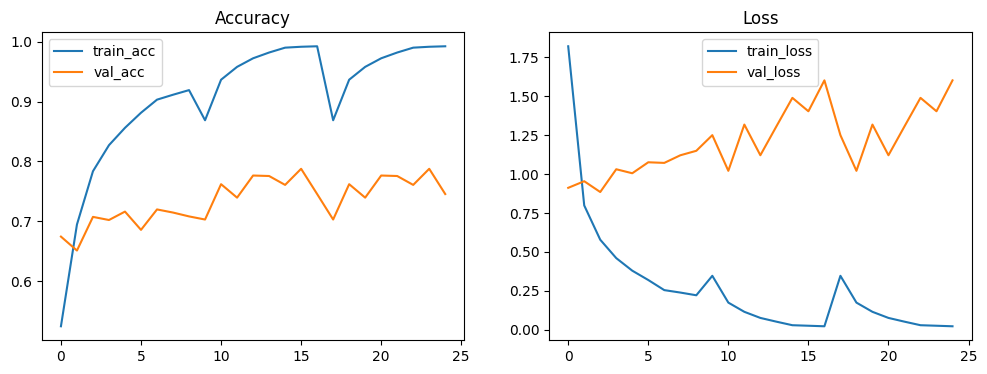

In [35]:
import matplotlib.pyplot as plt

# combine history objects (if both stages ran)
def combine_histories(h1, h2):
    history = {}
    for k in h1.history.keys():
        history[k] = h1.history[k] + h2.history.get(k, [])
    return history

hist = combine_histories(history1, history2) if ('history2' in globals()) else history1.history

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(hist['accuracy'], label='train_acc')
plt.plot(hist.get('val_accuracy', []), label='val_acc')
plt.title("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(hist['loss'], label='train_loss')
plt.plot(hist.get('val_loss', []), label='val_loss')
plt.title("Loss")
plt.legend()
plt.show()


In [37]:
checkpoint = ModelCheckpoint("vgg16_best.keras", monitor="val_accuracy",
                             save_best_only=True, verbose=1)

early_stop = EarlyStopping(monitor="val_loss", patience=5,
                           restore_best_weights=True)

reduce_lr = ReduceLROnPlateau(monitor="val_loss",
                              factor=0.3,
                              patience=2,
                              min_lr=1e-7,
                              verbose=1)

callbacks = [checkpoint, early_stop, reduce_lr]


In [38]:
history1 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10,
    callbacks=callbacks
)


Epoch 1/10


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
/usr/local/lib/python3.11/dist-packages/keras/src/legacy/preprocessing/image.py:1263: UserWarning: This ImageDataGenerator specifies `featurewise_center`, but it hasn't been fit on any training data. Fit it first by calling `.fit(numpy_data)`.
  warnings.warn(


545/545 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step - accuracy: 0.8801 - loss: 0.3435
Epoch 1: val_accuracy improved from -inf to 0.98231, saving model to vgg16_best.keras
545/545 ━━━━━━━━━━━━━━━━━━━━ 102s 188ms/step - accuracy: 0.8801 - loss: 0.3434 - val_accuracy: 0.9823 - val_loss: 0.0692 - learning_rate: 2.5000e-06
Epoch 2/10
545/545 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - accuracy: 0.9591 - loss: 0.1203
Epoch 2: val_accuracy improved from 0.98231 to 0.99625, saving model to vgg16_best.keras
545/545 ━━━━━━━━━━━━━━━━━━━━ 87s 159ms/step - accuracy: 0.9591 - loss: 0.1203 - val_accuracy: 0.9962 - val_loss: 0.0246 - learning_rate: 2.5000e-06
Epoch 3/10
545/545 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - accuracy: 0.9707 - loss: 0.0860
Epoch 3: val_accuracy did not improve from 0.99625
545/545 ━━━━━━━━━━━━━━━━━━━━ 86s 158ms/step - accuracy: 0.9707 - loss: 0.0860 - val_accuracy: 0.9946 - val_loss: 0.0170 - learning_rate: 2.5000e-06
Epoch 4/10
545/545 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step - accuracy: 0.9809 - l

In [40]:
from tensorflow.keras.optimizers import Adam

# Unfreeze last layers (block5)
for layer in base_model.layers:
    if "block5" in layer.name:
        layer.trainable = True
    else:
        layer.trainable = False

# Recompile with a very small learning rate
model.compile(
    optimizer=Adam(1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Continue fine-tuning
history_finetune = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10,
    callbacks=callbacks
)


Epoch 1/10
545/545 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step - accuracy: 0.9877 - loss: 0.0374
Epoch 1: val_accuracy did not improve from 0.99946
545/545 ━━━━━━━━━━━━━━━━━━━━ 93s 164ms/step - accuracy: 0.9877 - loss: 0.0374 - val_accuracy: 0.9995 - val_loss: 0.0020 - learning_rate: 1.0000e-05
Epoch 2/10
545/545 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step - accuracy: 0.9940 - loss: 0.0190
Epoch 2: val_accuracy did not improve from 0.99946
545/545 ━━━━━━━━━━━━━━━━━━━━ 87s 159ms/step - accuracy: 0.9940 - loss: 0.0191 - val_accuracy: 0.9995 - val_loss: 0.0021 - learning_rate: 1.0000e-05
Epoch 3/10
545/545 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - accuracy: 0.9960 - loss: 0.0125
Epoch 3: val_accuracy improved from 0.99946 to 1.00000, saving model to vgg16_best.keras
545/545 ━━━━━━━━━━━━━━━━━━━━ 87s 159ms/step - accuracy: 0.9960 - loss: 0.0125 - val_accuracy: 1.0000 - val_loss: 5.5134e-04 - learning_rate: 1.0000e-05
Epoch 4/10
545/545 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - accuracy: 0.9955 - loss: 0.0119
Epoch 4: 

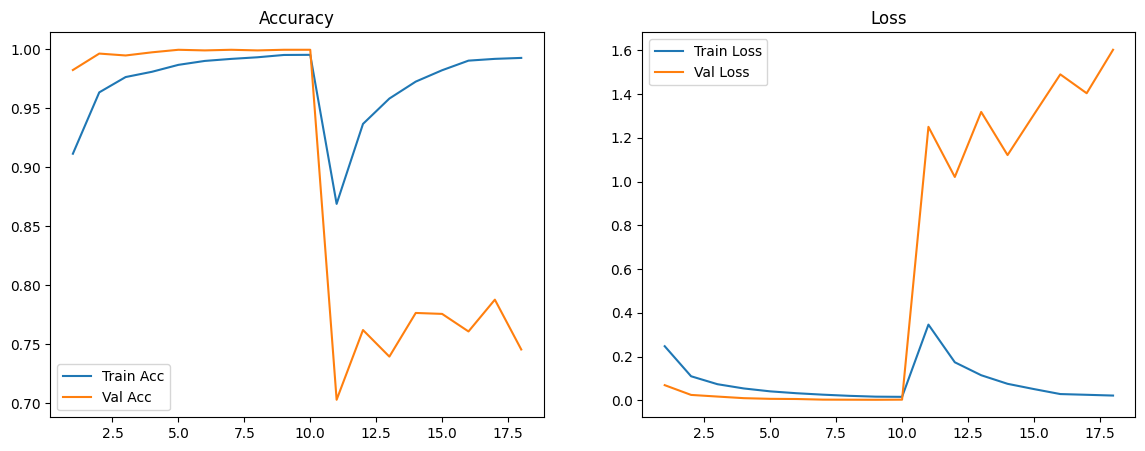

In [41]:
def plot_history(h1, h2):
    history = {}
    for k in h1.history:
        history[k] = h1.history[k] + h2.history[k]

    epochs = range(1, len(history['accuracy'])+1)

    plt.figure(figsize=(14,5))

    # Accuracy
    plt.subplot(1,2,1)
    plt.plot(epochs, history['accuracy'], label='Train Acc')
    plt.plot(epochs, history['val_accuracy'], label='Val Acc')
    plt.title("Accuracy")
    plt.legend()

    # Loss
    plt.subplot(1,2,2)
    plt.plot(epochs, history['loss'], label='Train Loss')
    plt.plot(epochs, history['val_loss'], label='Val Loss')
    plt.title("Loss")
    plt.legend()

    plt.show()

plot_history(history1, history2)


117/117 ━━━━━━━━━━━━━━━━━━━━ 14s 113ms/step


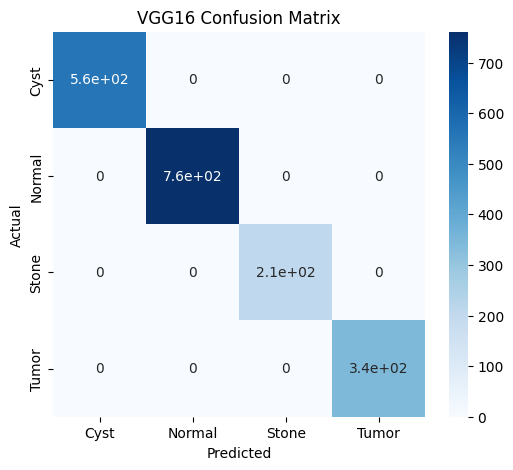

              precision    recall  f1-score   support

        Cyst       1.00      1.00      1.00       556
      Normal       1.00      1.00      1.00       761
       Stone       1.00      1.00      1.00       206
       Tumor       1.00      1.00      1.00       342

    accuracy                           1.00      1865
   macro avg       1.00      1.00      1.00      1865
weighted avg       1.00      1.00      1.00      1865



In [42]:
y_true = val_gen.classes
y_pred = np.argmax(model.predict(val_gen), axis=1)
labels = list(train_gen.class_indices.keys())

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, cmap="Blues",
            xticklabels=labels, yticklabels=labels)
plt.title("VGG16 Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print(classification_report(y_true, y_pred, target_names=labels))
